In [1028]:
import alphashape
import numpy as np
import os
import pandas as pd


def make_alpha_hull(xy, alpha=1):
    alpha_shape = alphashape.alphashape(xy, alpha)
    xH, yH = alpha_shape.boundary.coords.xy
    return np.vstack([xH, yH]).T


all_data = []
for keyword in ['random', 'kmeans']:
    df = pd.read_csv(os.path.join('data', 'embeddings', f'polymers-umap-{keyword}.txt'), header=None, names=['Sequence', 'Z0', 'Z1'])
    all_data.append(df)

orig_data = pd.concat(all_data)
orig_hull = make_alpha_hull(orig_data.loc[:, 'Z0':'Z1'])

In [1052]:
base = make_base(degree=4)
token_random = featurize(all_data[0].loc[:, 'Sequence'].values, base)
token_kmeans = featurize(all_data[1].loc[:, 'Sequence'].values, base)

Finding 21 patterns: ['A', 'AA', 'AAA', 'AAAA', 'AAAB', 'AAB', 'AABA', 'AABB', 'AB', 'ABA', 'ABAB', 'ABB', 'ABBA', 'ABBB', 'B', 'BAAB', 'BAB', 'BABB', 'BB', 'BBB', 'BBBB']


  0%|          | 0/1016 [00:00<?, ?it/s]

  0%|          | 0/1022 [00:00<?, ?it/s]

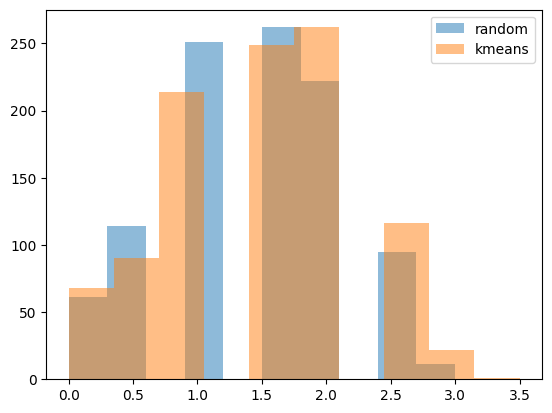

In [1061]:
k = 6
plt.hist(token_random[:, k], alpha=0.5, label='random')
plt.hist(token_kmeans[:, k], alpha=0.5, label='kmeans')
plt.legend()

In [1169]:
import torch

if torch.cuda.is_available():
    device = "cuda:0"
else:
    device = "cpu"

device = torch.device(device)
print(device)

cpu


In [1150]:
import glob
import json
import os

data = {}
data_files = sorted(glob.glob(os.path.join('data', 'embeddings', '2024-02-27', 'embeddings*.json')))
# data_files = sorted(glob.glob(os.path.join('/Users/wfr5091/Downloads', 'small-batch-embeddings', 'embeddings*.json')))
for f in data_files:
    with open(f, 'r') as fid:
        buffer = json.load(fid)
    data.update(buffer)
print(f'read {len(data)} records from {len(data_files)} files')

read 18791 records from 24 files


In [1135]:
data = {}

In [1151]:
# augment with the original data, which was distributed differently
buffer = {}
for r in orig_data.values:
    buffer[r[0]] = [r[1:].tolist()]
data.update(buffer)
print(f'read {len(buffer)} new records for a total of {len(data)} records')

read 2014 new records for a total of 20804 records


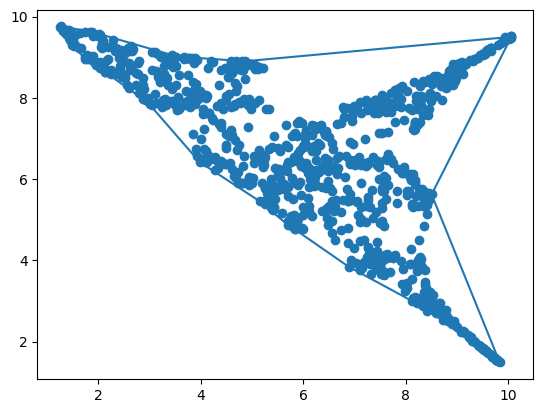

In [1209]:
train_df = pd.read_csv(os.path.join('data', 'embeddings', '2024-08-21', f'kmeans-mi-2024-08-21-train.csv'), index_col=0)
train_hull = make_alpha_hull(train_df.loc[:, 'Z0':'Z1'].values, alpha=0.2)
plt.scatter(*train_df.loc[:, 'Z0':'Z1'].values.T)
plt.plot(*train_hull.T)

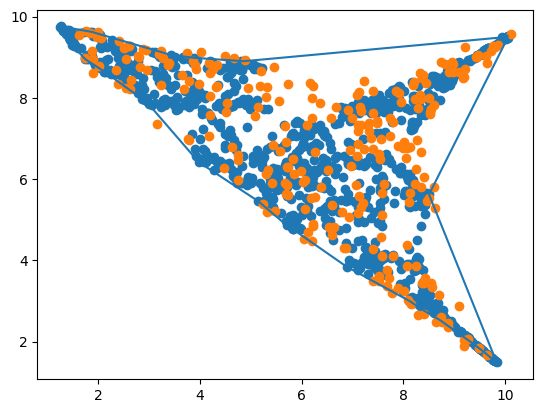

In [1211]:
train_df = pd.read_csv(os.path.join('data', 'embeddings', '2024-08-21', f'kmeans-mi-2024-08-21-train.csv'), index_col=0)
train_data = {}
for r in train_df.values:
    train_data[r[0]] = [r[1:].tolist()]
    
test_df = pd.read_csv(os.path.join('data', 'embeddings', '2024-08-21', f'kmeans-mi-2024-08-21-test.csv'), index_col=0)
test_data = {}
for r in test_df.values:
    test_data[r[0]] = [r[1:].tolist()]
    
plt.scatter(*train_df.loc[:, 'Z0':'Z1'].values.T)
plt.scatter(*test_df.loc[:, 'Z0':'Z1'].values.T)
plt.plot(*train_hull.T)    

In [1152]:
def seq_to_tensor(seq):
    AB = {'A': 0, 'B': 1}
    return torch.tensor([AB[it] for it in seq]).float() 

keys = sorted(data.keys())
x = torch.vstack([seq_to_tensor(k) for k in keys]).unsqueeze(1)  # unsqueeze for GRU
y = torch.tensor([data[k] for k in keys]).squeeze(1).float()
print(x.shape, y.shape)

torch.Size([20804, 1, 20]) torch.Size([20804, 2])


In [1153]:
import numpy as np

is_60_40 = np.argwhere(x.sum(dim=2) == 8)[0]
print(x[is_60_40].shape, y[is_60_40].shape)

torch.Size([4425, 1, 20]) torch.Size([4425, 2])


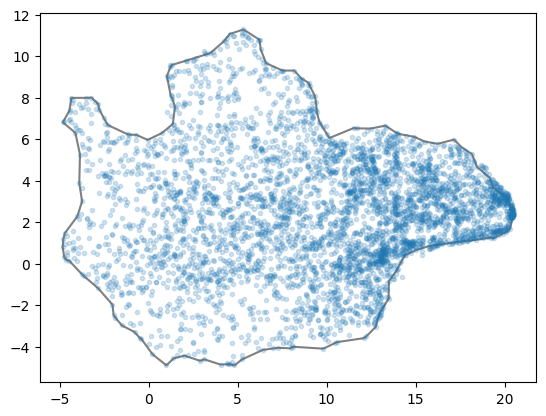

In [1154]:
plt.plot(*y[is_60_40].numpy().T, '.', alpha=0.20, rasterized=True)
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

In [1155]:
sequences = keys

In [1156]:
import torch
import model_utils

# load the RNN
model_ensemble = []
model_path = os.path.join('models', 'gru-opt-cv10-sym')
for i in range(10):
    model = torch.jit.load(os.path.join(model_path, f'fold-{i:02d}-scripted.pt'), map_location='cpu')
    model.eval()
    model_ensemble.append(model)

AB = {'A': 0, 'B': 1}
int_seq = np.array([[int(AB[x]) for x in s] for s in sequences])

predictions = []
for model in model_ensemble:
    out = model_utils.predict_from_model(model, int_seq)
    predictions.append(out)
z_pred = np.array(predictions).mean(axis=0)

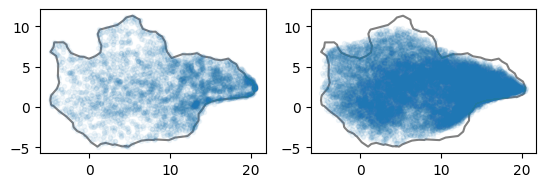

In [1159]:
fig, axes = plt.subplots(1, 2)
ax = axes[0]
ax.plot(*y[is_60_40].numpy().T, '.', alpha=0.05, rasterized=True)
ax.plot(*orig_hull.T, '-', color='grey', zorder=-1)
ax.set_aspect('equal')
ax = axes[1]
ax.plot(*z_pred.T, '.', alpha=0.05, rasterized=True)
ax.plot(*orig_hull.T, '-', color='grey', zorder=-1)
ax.set_aspect('equal')

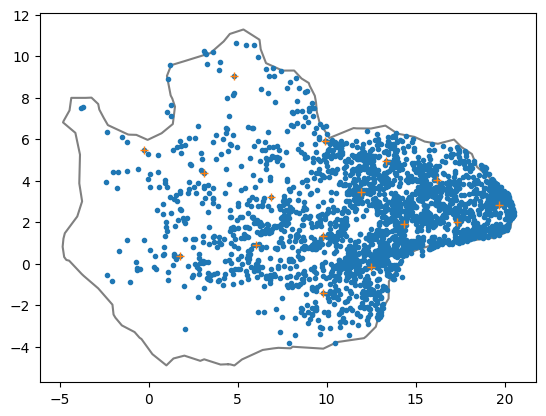

In [1107]:
from sklearn import cluster

# z0 = orig_data.loc[:, 'Z0':'Z1'].values
z0 = y[is_60_40].numpy()

km = cluster.KMeans(n_clusters=16, random_state=0)
km.fit(z0)
center_ids = []
for c in km.cluster_centers_:
    center_ids.append(np.argmin(np.linalg.norm(z0-c, axis=1)))

plt.plot(*z0.T, '.')
plt.plot(*z0[center_ids].T, '+')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

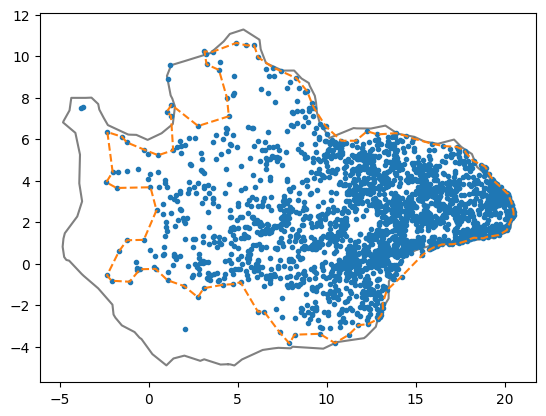

In [1106]:
z0 = y[is_60_40].numpy()
new_hull = make_alpha_hull(z0)

plt.plot(*z0.T, '.')
plt.plot(*new_hull.T, '--')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

In [1111]:
idx

14

In [1114]:
idx = np.argmin(z0[center_ids, 0])
seq_to_plot = x[is_60_40].squeeze(1).numpy()[center_ids]
AB = 'AB'
for s in seq_to_plot[[idx]]:
    print(''.join([AB[int(it)] for it in s]))

AABABBABAAAAABBBAABA


In [1160]:
import numpy as np
from sklearn import model_selection
from torch.utils.data import DataLoader, TensorDataset, Subset

ds = TensorDataset(x[is_60_40], y[is_60_40])

train_idx, test_idx = model_selection.train_test_split(np.arange(len(ds)), train_size=0.90, random_state=0, shuffle=True)

dl_train = DataLoader(Subset(ds, indices=train_idx), batch_size=256, shuffle=True)
dl_test = DataLoader(Subset(ds, indices=test_idx), batch_size=1024, shuffle=False)

In [1212]:
def seq_to_tensor(seq):
    AB = {'A': 0, 'B': 1}
    return torch.tensor([AB[it] for it in seq]).float() 

train_keys = sorted(train_data.keys())
train_x = torch.vstack([seq_to_tensor(k) for k in train_keys]).unsqueeze(1)  # unsqueeze for GRU
train_y = torch.tensor([train_data[k] for k in train_keys]).squeeze(1).float()
print(train_x.shape, train_y.shape)

ds_train = TensorDataset(train_x, train_y)
dl_train = DataLoader(ds_train, batch_size=256, shuffle=True)

test_keys = sorted(test_data.keys())
test_x = torch.vstack([seq_to_tensor(k) for k in test_keys]).unsqueeze(1)  # unsqueeze for GRU
test_y = torch.tensor([test_data[k] for k in test_keys]).squeeze(1).float()
print(test_x.shape, test_y.shape)

ds_test = TensorDataset(test_x, test_y)
dl_test = DataLoader(ds_test, batch_size=1024, shuffle=False)

torch.Size([1022, 1, 20]) torch.Size([1022, 2])
torch.Size([256, 1, 20]) torch.Size([256, 2])


In [1411]:
from torch import nn


class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, layer_dim, output_dim, dropout_prob=0):
        super(GRUModel, self).__init__()

        self.hidden_dim = hidden_dim
        self.bn = nn.BatchNorm1d(2 * hidden_dim)
        self.layer_dim = layer_dim

        self.rnn = nn.GRU(
            input_dim, hidden_dim, layer_dim,
            batch_first=True, dropout=dropout_prob,
            bidirectional=True
        )
        self.act = nn.LeakyReLU()
        self.dense = nn.Linear(2 * hidden_dim, output_dim)
        
    #     self.init_weights()
    # 
    # def init_weights(self):
    #    for name, param in self.named_parameters():
    #        if 'weight' in name:
    #            nn.init.xavier_uniform_(param)
    #        elif 'bias' in name:
    #            nn.init.constant_(param, 0.0)

    def embed(self, x):
        out, hn = self.rnn(x)
        out = torch.cat((hn[-2, :, :], hn[-1, :, :]), dim=1)

        return out

    def forward(self, x):
        out = self.embed(x)
        out = self.bn(out)
        out = self.act(out)
        out = self.dense(out)

        return out    
    
    
class MLPModel(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, act_fn=nn.LeakyReLU(), use_batch_norm=True, dropout_rate=0.0):
        super(MLPModel, self).__init__()

        self.act = act_fn
        self.use_batch_norm = use_batch_norm

        layers = []
        for i, h in enumerate(hidden_dims):
            if i == 0:
                layers.append(nn.Linear(input_dim, h))
            else:
                layers.append(nn.Linear(hidden_dims[i-1], h))
            
            if use_batch_norm:
                layers.append(nn.BatchNorm1d(h))
            
            layers.append(self.act)
            
            if dropout_rate > 0:
                layers.append(nn.Dropout(dropout_rate))
        
        layers.append(nn.Linear(hidden_dims[-1], output_dim))

        self.dense = nn.Sequential(*layers)

    def forward(self, x):
        return self.dense(x)


class GRUplusMLP(nn.Module):
    def __init__(self, input_dim, gru_hidden_dim, gru_layers, gru_output_dim, mlp_hidden_dims, output_dim, act_fn=nn.LeakyReLU()):
        super(GRUplusMLP, self).__init__()
        self.gru = GRUModel(input_dim, gru_hidden_dim, gru_layers, gru_output_dim, dropout_prob=0.0)
        # self.bn = nn.BatchNorm1d(gru_output_dim)
        self.mlp = MLPModel(gru_output_dim, mlp_hidden_dims, output_dim, act_fn)
        
    def forward(self, x):
        x = self.gru(x)
        # x = self.bn(x)
        x = self.mlp(x)
        return x

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
    

from torch.nn import TransformerEncoder, TransformerEncoderLayer
from torch import functional as F

class TransformerModel(nn.Module):
    def __init__(self, input_dim=2, d_model=8, nhead=2, num_layers=2, dim_feedforward=16, dropout=0.1, output_dim=2):
        super(TransformerModel, self).__init__()
        self.embedding = nn.Linear(input_dim, d_model)
        encoder_layers = TransformerEncoderLayer(d_model, nhead, dim_feedforward, dropout)
        self.transformer_encoder = TransformerEncoder(encoder_layers, num_layers)
        self.fc = nn.Linear(d_model, output_dim)
        
    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(1, 0, 2)  # (seq_len, batch, d_model)
        x = self.transformer_encoder(x)
        x = x.mean(dim=0)  # Average pooling over sequence length
        return self.fc(x)
   
   
class SimpleAttentionModel(nn.Module):
    def __init__(self, input_dim=2, hidden_dim=8, output_dim=2):
        super(SimpleAttentionModel, self).__init__()
        self.embedding = nn.Linear(input_dim, hidden_dim)
        self.attention = nn.Linear(hidden_dim, 1)
        self.fc = nn.Linear(hidden_dim, output_dim)
        
    def forward(self, x):
        x = self.embedding(x)
        attention_weights = torch.softmax(self.attention(x), dim=1)
        context_vector = torch.sum(attention_weights * x, dim=1)
        return self.fc(context_vector)   
    
    
class CNNRNNModel(nn.Module):
       def __init__(self, input_dim, cnn_filters, rnn_hidden, output_dim):
           super(CNNRNNModel, self).__init__()
           self.cnn = nn.Conv1d(input_dim, cnn_filters, kernel_size=3, padding=1)
           self.rnn = nn.GRU(cnn_filters, rnn_hidden, batch_first=True)
           self.fc = nn.Linear(rnn_hidden, output_dim)
           self.act = nn.ReLU()
       
       def forward(self, x):
           x = x.transpose(1, 2)  # (batch, input_dim, seq_len)
           x = self.act(self.cnn(x))
           x = x.transpose(1, 2)  # (batch, seq_len, cnn_filters)
           _, hn = self.rnn(x)
           return self.fc(hn[-1])    
    
   
def mse_loss_fwd_rev(fwd, rev, y):
    "averages coordinates from forward and backward pass"
    return 0.5 * (torch.nn.MSELoss()(fwd, y) + torch.nn.MSELoss()(rev, y))


def sym_loss(fwd, rev, y, alpha=1.0):
    "averages coordinates from forward and backward pass"
    avg = torch.nn.MSELoss()(0.5*(fwd + rev), y)
    sym = torch.nn.MSELoss()(fwd, rev)
    return avg + alpha * sym


def cycle_loss(fwd, rev, y, alpha=0.5, reduction='mean'):
    "penalizes the LSTM for encoding differently on forward and backward pass"
    L_fwd = torch.nn.MSELoss(reduction=reduction)(fwd, y)
    L_rev = torch.nn.MSELoss(reduction=reduction)(rev, y)
    L_cyc = torch.nn.MSELoss(reduction=reduction)(fwd, rev)
    return L_fwd + L_rev + alpha * L_cyc

def flip_last_dim(tensor):
    if len(tensor.shape) == 3:
        permuted = tensor.permute(0, 2, 1)
        flipped = torch.fliplr(permuted)
        result = flipped.permute(0, 2, 1)
    elif len(tensor.shape) == 2:
        result = torch.fliplr(tensor)
    else:
        raise ValueError('Expected a tensor with 2 or 3 dimensions')
    return result

## sparsenn

In [1382]:
import sys
sys.path.append('../sparse-nns')
import sparsenn

model = sparsenn.RegularizedMLP(20, (128, 64, 16), 2, activation=nn.LeakyReLU())

best_loss = np.inf
best_model = None

loss_fn = sym_loss
num_epochs = 800
learning_rate = 0.01
lmbda_reg = 1e-6
n_print = 80
verbose = True

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [946]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [1383]:
from copy import deepcopy
import tqdm.notebook

# Train the model
model.train()
for epoch in tqdm.notebook.tqdm(range(num_epochs), disable=(not verbose)):
    train_loss = 0.0

    for (batchX, batchy) in dl_train:

        optimizer.zero_grad()

        fwd = model(batchX.squeeze(1))
        rev = model(flip_last_dim(batchX).squeeze(1))
        reg_loss = model.regularization_loss()
        
        loss = loss_fn(fwd, rev, batchy)
        total_loss = loss + lmbda_reg * reg_loss
        total_loss.backward()
        
        optimizer.step()

        train_loss += loss.item()

    train_loss /= len(dl_train)
    scheduler.step(train_loss)

    if train_loss < best_loss:
        best_loss = train_loss
        best_model = deepcopy(model)
    
    if n_print > 0 and (epoch+1) % int(num_epochs / n_print) == 0:
        with torch.no_grad():
            test_loss = 0
            for (tX, ty) in dl_test:
                test_loss += loss_fn(model(tX.squeeze(1)), model(flip_last_dim(tX).squeeze(1)), ty).item()
            test_loss /= len(dl_test)
        print(f"Epoch: {epoch+1:5d}, loss: {train_loss:1.5f}, L0R: {reg_loss.item():.2f} test: {test_loss:1.5f}")

print(best_loss)

  0%|          | 0/800 [00:00<?, ?it/s]

Epoch:    10, loss: 10.76455, L0R: 9786.21 test: 6.56365
Epoch:    20, loss: 8.57390, L0R: 9755.12 test: 10.82189
Epoch:    30, loss: 7.74504, L0R: 9742.99 test: 8.47990
Epoch:    40, loss: 8.81018, L0R: 9739.90 test: 5.95397
Epoch:    50, loss: 8.57392, L0R: 9736.04 test: 9.17116
Epoch:    60, loss: 9.49089, L0R: 9735.39 test: 11.63435
Epoch:    70, loss: 8.36480, L0R: 9735.14 test: 7.52520
Epoch:    80, loss: 9.33311, L0R: 9735.00 test: 9.86298
Epoch:    90, loss: 8.90221, L0R: 9734.93 test: 6.19271
Epoch:   100, loss: 9.06271, L0R: 9734.92 test: 9.02384
Epoch:   110, loss: 7.83805, L0R: 9734.91 test: 8.47311
Epoch:   120, loss: 7.97819, L0R: 9734.91 test: 7.65583
Epoch:   130, loss: 9.13304, L0R: 9734.91 test: 9.69986
Epoch:   140, loss: 6.95682, L0R: 9734.91 test: 6.36583
Epoch:   150, loss: 6.96860, L0R: 9734.91 test: 5.20655
Epoch:   160, loss: 7.30920, L0R: 9734.91 test: 5.04837
Epoch:   170, loss: 9.20707, L0R: 9734.91 test: 5.21248
Epoch:   180, loss: 8.54495, L0R: 9734.91 tes

In [ ]:
from sparsenn import viz

# Render the optimized architecture 
b = best_model
# b = model
g = viz.gated_connections_graph(b)
fig = viz.render_sparse_nn(g)

## old models

In [1162]:
import torch
import torch.nn as nn

class ResidualBlock(nn.Module):
    def __init__(self, dim, use_batch_norm=True, dropout_rate=0.0):
        super(ResidualBlock, self).__init__()
        
        self.linear1 = nn.Linear(dim, dim)
        self.linear2 = nn.Linear(dim, dim)
        self.act = nn.LeakyReLU()
        self.use_batch_norm = use_batch_norm
        
        if use_batch_norm:
            self.bn1 = nn.BatchNorm1d(dim)
            self.bn2 = nn.BatchNorm1d(dim)
        
        self.dropout = nn.Dropout(dropout_rate) if dropout_rate > 0 else None

    def forward(self, x):
        identity = x
        
        out = self.linear1(x)
        if self.use_batch_norm:
            out = self.bn1(out)
        out = self.act(out)
        if self.dropout is not None:
            out = self.dropout(out)
        
        out = self.linear2(out)
        if self.use_batch_norm:
            out = self.bn2(out)
        
        out += identity  # Residual connection
        out = self.act(out)
        
        return out

class MLPModelWithResidual(nn.Module):
    def __init__(self, input_dim, hidden_dims, output_dim, use_batch_norm=True, dropout_rate=0.0):
        super(MLPModelWithResidual, self).__init__()
        
        layers = []
        current_dim = input_dim
        
        # Initial layer to map input_dim to the first hidden_dim
        layers.append(nn.Linear(input_dim, hidden_dims[0]))
        if use_batch_norm:
            layers.append(nn.BatchNorm1d(hidden_dims[0]))
        layers.append(nn.LeakyReLU())
        
        # Residual blocks
        for hidden_dim in hidden_dims:
            layers.append(ResidualBlock(hidden_dim, use_batch_norm, dropout_rate))
        
        self.residual_blocks = nn.Sequential(*layers)
        self.final_linear = nn.Linear(hidden_dims[-1], output_dim)

    def forward(self, x):
        x = self.residual_blocks(x)
        return self.final_linear(x)
    

class GRUplusResidualMLP(nn.Module):
    def __init__(self, input_dim, gru_hidden_dim, gru_layers, gru_output_dim, mlp_hidden_dims, output_dim):
        super(GRUplusResidualMLP, self).__init__()
        self.gru = GRUModel(input_dim, gru_hidden_dim, gru_layers, gru_output_dim, dropout_prob=0.0)
        self.bn = nn.BatchNorm1d(gru_output_dim)
        self.mlp = MLPModelWithResidual(gru_output_dim, mlp_hidden_dims, output_dim)
        
    def forward(self, x):
        x = self.gru(x)
        x = self.bn(x)
        x = self.mlp(x)
        return x

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)    

In [1163]:
class CNN1DRegressor(nn.Module):
    def __init__(self, seq_length=20, output_dim=2, num_filters=[16, 32], 
                 kernel_sizes=[3, 5], fc_layers=[32], dropout_rate=0.5):
        super(CNN1DRegressor, self).__init__()
        
        self.conv_layers = nn.ModuleList()
        self.fc_layers = nn.ModuleList()
        
        # Convolutional layers
        in_channels = 1
        for i, (out_channels, kernel_size) in enumerate(zip(num_filters, kernel_sizes)):
            conv = nn.Sequential(
                nn.Conv1d(in_channels, out_channels, kernel_size, padding=kernel_size//2),
                nn.BatchNorm1d(out_channels),
                nn.ReLU(),
                nn.MaxPool1d(2)
            )
            self.conv_layers.append(conv)
            in_channels = out_channels
            seq_length = seq_length // 2
        
        # Fully connected layers
        fc_input_dim = num_filters[-1] * seq_length
        for fc_dim in fc_layers:
            fc = nn.Sequential(
                nn.Linear(fc_input_dim, fc_dim),
                nn.BatchNorm1d(fc_dim),
                nn.ReLU(),
                nn.Dropout(dropout_rate)
            )
            self.fc_layers.append(fc)
            fc_input_dim = fc_dim
        
        self.output_layer = nn.Linear(fc_input_dim, output_dim)
        
    def forward(self, x):
        for conv in self.conv_layers:
            x = conv(x)
        x = x.view(x.size(0), -1)
        for fc in self.fc_layers:
            x = fc(x)
        x = self.output_layer(x)
        return x

In [1539]:
class GRUplusMLP(nn.Module):
    def __init__(self, input_dim, gru_hidden_dim, gru_layers, gru_output_dim, mlp_hidden_dims, output_dim, act_fn=nn.LeakyReLU()):
        super(GRUplusMLP, self).__init__()
        self.gru = GRUModel(input_dim, gru_hidden_dim, gru_layers, gru_output_dim, dropout_prob=0.20)
        self.bn = nn.BatchNorm1d(gru_output_dim)
        self.mlp = MLPModel(gru_output_dim, mlp_hidden_dims, output_dim, act_fn)
        
    def forward(self, x):
        x = self.gru(x)
        x = self.bn(x)
        x = self.mlp(x)
        return x

    def init_weights(self):
        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)
                
def sym_loss_L1(fwd, rev, y, alpha=1.0):
    "averages coordinates from forward and backward pass"
    avg = torch.nn.L1Loss()(0.5*(fwd + rev), y)
    sym = torch.nn.L1Loss()(fwd, rev)
    return avg + alpha * sym                

In [1543]:
from torch.optim.lr_scheduler import ReduceLROnPlateau

# model = GRUModel(20, 7, 3, 2, 0).to(device)  # optimal from before

# model = GRUModel(20, 20, 9, 2, 0).to(device)  # best so far for the original dataset
# model = GRUModel(20, 20, 12, 2, 0).to(device)

# model = MLPModel(20, (128, 57, 12), 2).to(device)  # optimal from before
# model = MLPModel(20, (32, 16, 8, 4, ), 2).to(device)  # trying new parameters

# model = MLPModelWithResidual(20, (128, 57, 12), 2).to(device)

# model = GRUplusMLP(20, 64, 8, 64, (32, 16, ), 2).to(device)  # test RMSE = 0.88
model = GRUplusMLP(20, 48, 4, 48, (32, 16, ), 2, act_fn=nn.LeakyReLU()).to(device)  # test RMSE = ???
# model = GRUplusResidualMLP(20, 16, 4, 64, (128, 64, 16, ), 2).to(device)

# model = TransformerModel(input_dim=20, d_model=16, nhead=4, num_layers=2, dim_feedforward=64, dropout=0, output_dim=2)
# model = SimpleAttentionModel(20, 16, 2)
# model = CNNRNNModel(20, 16, 16, 2)

best_loss = np.inf
best_model = None

loss_fn = sym_loss # cycle_loss
num_epochs = 400
learning_rate = 0.010
n_print = num_epochs // 10
verbose = True

optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=5)

In [1367]:
optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate/2)

In [1544]:
from copy import deepcopy
import tqdm.notebook

# Train the model
model.train()
for epoch in tqdm.notebook.tqdm(range(num_epochs), disable=(not verbose)):
    train_loss = 0.0

    k = 0
    for (batchX, batchy) in dl_train:

        optimizer.zero_grad()

        # fwd = model(batchX.squeeze(1))
        # rev = model(flip_last_dim(batchX).squeeze(1))
        
        fwd = model(batchX)
        rev = model(flip_last_dim(batchX))
        
        loss = loss_fn(fwd, rev, batchy)
        loss.backward()
        
        optimizer.step()

        train_loss += loss.item() * batchX.shape[0]
        k += batchX.shape[0]

    train_loss /= k
    scheduler.step(train_loss)
    
    if train_loss < best_loss:
        best_loss = train_loss
        best_model = deepcopy(model)
    
    if n_print > 0 and (epoch+1) % int(num_epochs / n_print) == 0:
        model.eval()
        with torch.no_grad():
            test_loss = 0
            k = 0
            for (tX, ty) in dl_test:
                # test_loss += loss_fn(model(tX.squeeze(1)), model(flip_last_dim(tX).squeeze(1)), ty).item() * tX.shape[0]
                test_loss += loss_fn(model(tX), model(flip_last_dim(tX)), ty).item() * tX.shape[0]
                k += tX.shape[0]
            test_loss /= k
        print("Epoch: %5d, loss: %1.5f, test: %1.5f" % (epoch+1, train_loss, test_loss))
        model.train()

print(best_loss)

  0%|          | 0/400 [00:00<?, ?it/s]

Epoch:    10, loss: 6.49991, test: 5.31247
Epoch:    20, loss: 4.56543, test: 4.21338
Epoch:    30, loss: 2.55765, test: 2.38890
Epoch:    40, loss: 1.79927, test: 1.85894
Epoch:    50, loss: 1.50133, test: 1.52196
Epoch:    60, loss: 1.22555, test: 1.36456
Epoch:    70, loss: 1.13681, test: 1.27218
Epoch:    80, loss: 1.06260, test: 1.21741
Epoch:    90, loss: 0.89044, test: 1.15843
Epoch:   100, loss: 0.87881, test: 1.14807
Epoch:   110, loss: 0.81921, test: 1.06762
Epoch:   120, loss: 0.74446, test: 1.05403
Epoch:   130, loss: 0.71726, test: 1.02048
Epoch:   140, loss: 0.66864, test: 0.99736
Epoch:   150, loss: 0.62741, test: 0.98726
Epoch:   160, loss: 0.65958, test: 0.99012
Epoch:   170, loss: 0.61737, test: 0.98012
Epoch:   180, loss: 0.63962, test: 0.97871
Epoch:   190, loss: 0.65259, test: 0.98517
Epoch:   200, loss: 0.63489, test: 0.97619
Epoch:   210, loss: 0.68186, test: 0.97430
Epoch:   220, loss: 0.65310, test: 0.97812
Epoch:   230, loss: 0.64831, test: 0.98008
Epoch:   24

0.9733686448848752 0.9568376053230019 0.9568643879427237


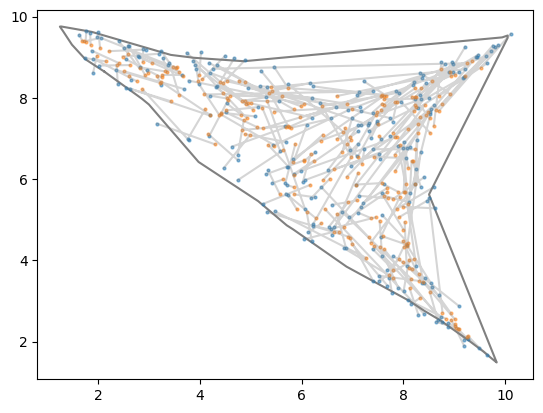

In [1545]:
import matplotlib.pyplot as plt

model = best_model
model.eval()

z_pred_fwd = np.zeros([0, 2])
z_pred_rev = np.zeros([0, 2])
z_real = np.zeros([0, 2])
# z_comp = np.zeros([0])
with torch.no_grad():
    for (batchX, batchy) in dl_test:
        # fwd = model(batchX.squeeze(1)).cpu().numpy()
        # rev = model(flip_last_dim(batchX).squeeze(1)).cpu().numpy()
        
        fwd = model(batchX).cpu().numpy()
        rev = model(flip_last_dim(batchX)).cpu().numpy()
        
        z_pred_fwd = np.vstack([z_pred_fwd, fwd])
        z_pred_rev = np.vstack([z_pred_rev, rev])
        z_real = np.vstack([z_real, batchy.cpu().numpy()])
        # z_comp = np.hstack([z_comp, batchX.cpu().numpy().sum(axis=1)])

# evaluate RMSE instead of sym cycle loss
rmse_fwd = np.sqrt(np.mean((z_pred_fwd - z_real)**2))
rmse_rev = np.sqrt(np.mean((z_pred_rev - z_real)**2))

z_pred = 0.5*(z_pred_fwd + z_pred_rev)
rmse_avg = np.sqrt(np.mean((z_pred - z_real)**2))
print(rmse_fwd, rmse_rev, rmse_avg)

z_diff = np.zeros([0, 2])
for i in range(z_pred.shape[0]):
    z_diff = np.vstack([z_diff, z_pred[i], z_real[i], np.nan * np.ones(2)])

plt.plot(*z_pred.T, '.', ms=4, c='tab:orange', alpha=0.5, rasterized=True)
im = plt.scatter(*z_real.T, s=4, c='tab:blue', alpha=0.5, rasterized=True)
# cbar = plt.colorbar(im)
plt.plot(*z_diff.T, '-', alpha=0.33, color='grey', rasterized=True)
# plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)
plt.plot(*train_hull.T, '-', color='grey', zorder=-1)

In [484]:
model(batchX).shape

torch.Size([1024, 1, 2])

In [161]:
pattern = 'AAAAAA'
kp = [it.count(pattern) for it in keys]
op = [it.count(pattern) for it in orig_data['Sequence']]
for it in [kp, op]:
    print(f'{np.mean(it):.4f} +/- {np.std(it)/np.sqrt(len(it)):.4f}')

0.1071 +/- 0.0023
0.2234 +/- 0.0131


In [104]:
np.sum(z_comp == 8)

1929

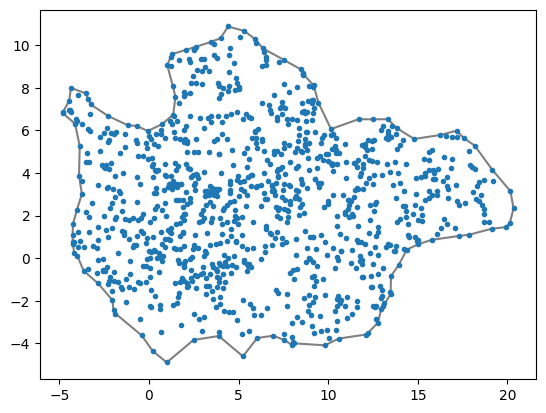

In [134]:
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values.T, '.')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

In [142]:
np.mean([it.count('AAAAA') for it in orig_data['Sequence']])

0.46062992125984253

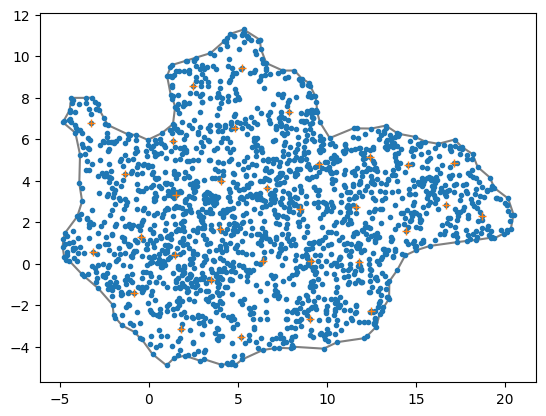

In [57]:
from sklearn import cluster

z0 = orig_data.loc[:, 'Z0':'Z1'].values
km = cluster.KMeans(n_clusters=32, random_state=0)
km.fit(z0)
center_ids = []
for c in km.cluster_centers_:
    center_ids.append(np.argmin(np.linalg.norm(z0-c, axis=1)))

plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values.T, '.')
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values[center_ids].T, '+')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

In [61]:
orig_data.iloc[center_ids]

,Sequence,Z0,Z1
238,ABABBBAAAABAABAABABA,12.420571,5.136292
552,BABAABBABAABAAAAABBA,4.014027,1.683533
297,ABBABAAABAAAABABBBAA,1.375304,5.925048
672,BABABABABAABAAAAABAB,9.033781,-2.672584
629,BABAABABAABABBBAAAAA,-3.136276,0.568418
464,BAAABBABABAABABAAAAB,16.667475,2.840583
237,ABABBABBBAAAAABAABAA,6.627234,3.634849
687,BABABBBAABABABAAAAAA,1.792373,-3.124115
899,BBABBAAAABAABABAAAAB,11.802217,0.082734
967,BBBAABABAAAABAABABAA,2.462739,8.557136


In [62]:
json_data = """{"AAABBBBABBBAAAABAAAA": [[3.801568031311035, -0.6019923686981201]], "AABAAAAABBBABBBBAAAA": [[6.548745155334473, -0.3458750545978546]], "AABABABABBABBAAAABAA": [[8.54725456237793, 2.554283380508423]], "ABAAAAABBABBBBAAABAA": [[12.411651611328125, 1.8428394794464111]], "ABABABABABAABABAABAA": [[17.038042068481445, 5.0185227394104]], "ABABBABBBAAAAABAABAA": [[6.504981994628906, 3.30476450920105]], "ABABBBAAAABAABAABABA": [[12.476449966430664, 4.924335956573486]], "ABABBBBBBABAAAAAAAAA": [[5.4797139167785645, -4.013937473297119]], "ABBAAAAABBAABABBABAA": [[4.336036205291748, 3.8063738346099854]], "ABBABAAABAAAABABBBAA": [[1.6522473096847534, 5.591573238372803]], "ABBABABAABABABAAAABA": [[15.103795051574707, 4.351380825042725]], "ABBBAAABAAABAAAABBBA": [[9.46753215789795, 4.482340335845947]], "ABBBBBAAAAAAAABABABA": [[-0.2394447922706604, 1.1239842176437378]], "BAAAAABABBBAAABBAABA": [[14.281103134155273, 1.8749425411224365]], "BAAAABBABBAAAABBBAAA": [[1.4023058414459229, 3.17733097076416]], "BAAABBABAAABABABBAAA": [[-2.654362916946411, 6.974529266357422]], "BAAABBABABAABABAAAAB": [[16.8122615814209, 2.899477481842041]], "BAABAAABAABAABBBABAA": [[5.240434169769287, 10.072861671447754]], "BAABAAABBBABAAAABAAB": [[18.61678123474121, 1.9342783689498901]], "BAABAABABABAAABBBAAA": [[4.958918571472168, 6.075101852416992]], "BABAABABAABABBBAAAAA": [[-2.892883062362671, 0.5824792385101318]], "BABAABBABAABAAAAABBA": [[3.827591896057129, 1.1584559679031372]], "BABAABBABBBAAAAAABAA": [[9.085463523864746, -0.010916714556515217]], "BABABABABAABAAAAABAB": [[9.259976387023926, -2.7022855281829834]], "BABABBBAABABABAAAAAA": [[1.9882436990737915, -3.4786500930786133]], "BABBAAABBABBAAAABAAA": [[1.3449599742889404, 0.5607780814170837]], "BABBABAABAAAAABBABAA": [[-1.6642740964889526, 4.759571075439453]], "BBAAAABABABBAAAAABAB": [[12.557597160339355, -2.2196383476257324]], "BBAABAABAABABAABABAA": [[7.685176849365234, 7.824875831604004]], "BBABBAAAABAABABAAAAB": [[11.974987983703613, -0.10764914751052856]], "BBABBABAAABBAABAAAAA": [[-1.0262466669082642, -1.0918080806732178]], "BBBAABABAAAABAABABAA": [[2.7598917484283447, 8.75721549987793]]}"""
embeddings = json.loads(json_data)

In [69]:
json_data = """{"AAABBBBABBBAAAABAAAA": [[3.801568031311035, -0.6019923686981201]], "AABAAAAABBBABBBBAAAA": [[6.548745155334473, -0.3458750545978546]], "AABABABABBABBAAAABAA": [[8.54725456237793, 2.554283380508423]], "ABAAAAABBABBBBAAABAA": [[12.411651611328125, 1.8428394794464111]], "ABABABABABAABABAABAA": [[17.038042068481445, 5.0185227394104]], "ABABBABBBAAAAABAABAA": [[6.504981994628906, 3.30476450920105]], "ABABBBAAAABAABAABABA": [[12.476449966430664, 4.924335956573486]], "ABABBBBBBABAAAAAAAAA": [[5.4797139167785645, -4.013937473297119]], "ABBAAAAABBAABABBABAA": [[4.336036205291748, 3.8063738346099854]], "ABBABAAABAAAABABBBAA": [[1.6522473096847534, 5.591573238372803]], "ABBABABAABABABAAAABA": [[15.103795051574707, 4.351380825042725]], "ABBBAAABAAABAAAABBBA": [[9.46753215789795, 4.482340335845947]], "ABBBBBAAAAAAAABABABA": [[-0.2394447922706604, 1.1239842176437378]], "BAAAAABABBBAAABBAABA": [[14.281103134155273, 1.8749425411224365]], "BAAAABBABBAAAABBBAAA": [[1.4023058414459229, 3.17733097076416]], "BAAABBABAAABABABBAAA": [[-2.654362916946411, 6.974529266357422]], "BAAABBABABAABABAAAAB": [[16.8122615814209, 2.899477481842041]], "BAABAAABAABAABBBABAA": [[5.240434169769287, 10.072861671447754]], "BAABAAABBBABAAAABAAB": [[18.61678123474121, 1.9342783689498901]], "BAABAABABABAAABBBAAA": [[4.958918571472168, 6.075101852416992]], "BABAABABAABABBBAAAAA": [[-2.892883062362671, 0.5824792385101318]], "BABAABBABAABAAAAABBA": [[3.827591896057129, 1.1584559679031372]], "BABAABBABBBAAAAAABAA": [[9.085463523864746, -0.010916714556515217]], "BABABABABAABAAAAABAB": [[9.259976387023926, -2.7022855281829834]], "BABABBBAABABABAAAAAA": [[1.9882436990737915, -3.4786500930786133]], "BABBAAABBABBAAAABAAA": [[1.3449599742889404, 0.5607780814170837]], "BABBABAABAAAAABBABAA": [[-1.6642740964889526, 4.759571075439453]], "BBAAAABABABBAAAAABAB": [[12.557597160339355, -2.2196383476257324]], "BBAABAABAABABAABABAA": [[7.685176849365234, 7.824875831604004]], "BBABBAAAABAABABAAAAB": [[11.974987983703613, -0.10764914751052856]], "BBABBABAAABBAABAAAAA": [[-1.0262466669082642, -1.0918080806732178]], "BBBAABABAAAABAABABAA": [[2.7598917484283447, 8.75721549987793]]}"""
embeddings = json.loads(json_data)

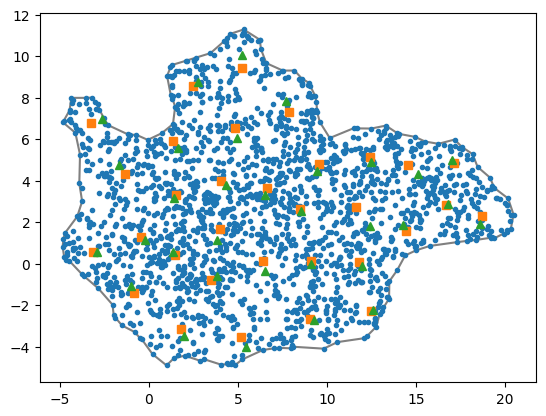

In [70]:
new_z_data = np.vstack(list(embeddings.values()))

plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values.T, '.')
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values[center_ids].T, 's')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

plt.plot(*new_z_data.T, '^')

In [105]:
new_sims = json.loads("""{"AAABBBBABBBAAAABAAAA": [[4.381252288818359, 0.01985207013785839], [4.952413558959961, -0.27741163969039917], [5.342206954956055, -0.2497330754995346], [4.777305603027344, -0.8483262658119202], [5.175142765045166, -0.2624131143093109], [5.774796485900879, -0.2435755878686905], [5.967403411865234, -0.7566969990730286], [5.502099514007568, -0.6620403528213501], [6.253932476043701, -0.5487338900566101], [6.591766834259033, -0.7562664151191711]], "AABAAAAABBBABBBBAAAA": [[5.853786468505859, 0.2901631295681], [6.392028331756592, 0.5060562491416931], [6.961159706115723, -0.10070932656526566], [7.313287734985352, -0.395468533039093], [8.723653793334961, 0.16470815241336823], [10.422222137451172, 0.18905478715896606], [10.631993293762207, 0.26590174436569214], [10.920794486999512, 0.3454624116420746], [11.328619003295898, -0.042096901684999466], [11.427692413330078, 0.14652538299560547]], "AABABABABBABBAAAABAA": [[8.342901229858398, 1.9540894031524658], [8.124744415283203, 2.0448391437530518], [9.121870040893555, 2.1045823097229004], [9.323055267333984, 2.9926226139068604], [10.207303047180176, 2.2176270484924316], [10.603522300720215, 2.8087942600250244], [10.436920166015625, 3.0211658477783203], [10.016474723815918, 2.749204158782959], [10.914801597595215, 3.321565628051758], [11.392911911010742, 3.3960378170013428]], "ABAAAAABBABBBBAAABAA": [[10.37423324584961, 1.847350001335144], [12.365954399108887, 2.3766157627105713], [12.812263488769531, 2.1029884815216064], [12.461553573608398, 2.7763028144836426], [12.321244239807129, 2.77541446685791], [12.848093032836914, 2.5323901176452637], [12.307941436767578, 2.623260498046875], [12.016674041748047, 2.5777177810668945], [12.196172714233398, 2.841458559036255], [12.937898635864258, 2.411280632019043]], "ABABABABABAABABAABAA": [[18.060741424560547, 4.520681381225586], [15.33215618133545, 5.380826473236084], [15.893284797668457, 4.6393656730651855], [15.594734191894531, 4.975815773010254], [15.085535049438477, 5.525062561035156], [15.399455070495605, 4.650092124938965], [16.364700317382812, 4.861716270446777], [15.86346435546875, 4.671618461608887], [14.691359519958496, 5.39860725402832], [14.978885650634766, 4.7428083419799805]], "ABABBABBBAAAAABAABAA": [[5.050414085388184, 3.8015382289886475], [5.924630641937256, 4.264420986175537], [6.30087947845459, 3.940054416656494], [6.227459907531738, 5.070920944213867], [6.285776138305664, 5.24146842956543], [6.277688980102539, 5.764808654785156], [6.16778564453125, 5.423289775848389], [6.132111549377441, 5.817594051361084], [6.2678022384643555, 7.285027980804443], [6.475729942321777, 7.071545124053955]], "ABABBBAAAABAABAABABA": [[12.432877540588379, 5.143340110778809], [12.181360244750977, 5.076950550079346], [12.183794975280762, 4.88387393951416], [12.179191589355469, 5.283205032348633], [14.036412239074707, 5.471268653869629], [12.155512809753418, 5.11858606338501], [13.335739135742188, 5.0282087326049805], [13.458205223083496, 5.561093330383301], [12.300512313842773, 5.474863529205322], [13.74167537689209, 5.056983470916748]], "ABABBBBBBABAAAAAAAAA": [[3.1291723251342773, -4.344503879547119], [3.652646541595459, -4.600546836853027], [3.3084423542022705, -4.636260032653809], [3.766300678253174, -4.291744232177734], [4.519124984741211, -4.485980987548828], [4.053027153015137, -4.494892597198486], [4.506156921386719, -4.2177534103393555], [4.239024639129639, -3.935812473297119], [4.1241631507873535, -4.559558391571045], [4.024868965148926, -3.942634344100952]], "ABBAAAAABBAABABBABAA": [[3.1253652572631836, 3.0441596508026123], [2.7287650108337402, 3.417722463607788], [2.4675192832946777, 3.1945884227752686], [3.104353427886963, 3.720930337905884], [2.1067311763763428, 3.1200129985809326], [2.652400255203247, 3.4353015422821045], [2.68483829498291, 3.4486324787139893], [3.4844093322753906, 3.698214054107666], [2.952293634414673, 3.2573728561401367], [3.8052515983581543, 3.7252566814422607]], "ABBABAAABAAAABABBBAA": [[1.4742342233657837, 5.382307529449463], [1.7591825723648071, 6.0879082679748535], [1.6738417148590088, 5.993493556976318], [1.7008663415908813, 6.907858371734619], [1.6394447088241577, 7.20349645614624], [2.0926454067230225, 7.410610675811768], [2.0699994564056396, 7.463992118835449], [1.5429065227508545, 6.896174907684326], [1.6589523553848267, 6.672867298126221], [2.3404042720794678, 6.694577217102051]], "ABBABABAABABABAAAABA": [[13.882426261901855, 4.028160572052002], [15.16878890991211, 3.9018290042877197], [15.026549339294434, 4.228918552398682], [15.434622764587402, 3.6958789825439453], [14.921547889709473, 4.2089457511901855], [15.323902130126953, 3.8092691898345947], [15.27058219909668, 3.898644208908081], [15.546385765075684, 3.4587295055389404], [13.897929191589355, 3.9693143367767334], [15.006378173828125, 4.136545181274414]], "ABBBAAABAAABAAAABBBA": [[6.645386695861816, 5.438843250274658], [7.581645488739014, 5.520082950592041], [7.606756687164307, 5.291154384613037], [7.181082248687744, 7.5417938232421875], [8.099724769592285, 6.135949611663818], [7.289087772369385, 7.800480842590332], [8.282115936279297, 8.84444522857666], [7.6715288162231445, 7.347843647003174], [8.634634017944336, 7.537227630615234], [8.48206901550293, 8.611078262329102]], "ABBBBBAAAAAAAABABABA": [[-0.6925626397132874, -1.0174670219421387], [-0.3617650270462036, 0.8610424995422363], [-0.6162625551223755, 1.3621903657913208], [-0.2312493920326233, 1.5286492109298706], [-0.56959068775177, 1.3889679908752441], [-0.020048437640070915, 2.2036874294281006], [0.4366317093372345, 1.5794129371643066], [-0.026712380349636078, 2.259345769882202], [-0.05838790535926819, 1.9044510126113892], [0.4039269983768463, 2.7266011238098145]], "BAAAAABABBBAAABBAABA": [[13.281102180480957, 1.3344799280166626], [15.241791725158691, 2.633272886276245], [14.827348709106445, 2.215564727783203], [15.803362846374512, 2.5200963020324707], [14.708742141723633, 2.5457825660705566], [16.572683334350586, 2.065613269805908], [16.149717330932617, 2.3260838985443115], [16.379798889160156, 2.1248111724853516], [15.78647518157959, 2.183661460876465], [15.248111724853516, 2.207693099975586]], "BAAAABBABBAAAABBBAAA": [[1.7176387310028076, 2.8603618144989014], [1.6246196031570435, 3.0333704948425293], [1.4975782632827759, 3.1977322101593018], [1.4507839679718018, 2.808478832244873], [1.613115668296814, 3.0842106342315674], [1.4996817111968994, 3.147702693939209], [1.8388057947158813, 3.1599762439727783], [1.564855694770813, 3.330596446990967], [1.4428213834762573, 2.837724447250366], [1.6700249910354614, 3.285928964614868]], "BAAABBABAAABABABBAAA": [[-3.1978600025177, 7.038280963897705], [-3.7590830326080322, 6.914938926696777], [-3.6756584644317627, 7.222019195556641], [-3.292843818664551, 6.861213207244873], [-3.3423964977264404, 6.72791051864624], [-3.086503267288208, 7.226218223571777], [-3.2020838260650635, 7.196563720703125], [-4.226733207702637, 7.152859687805176], [-3.6558103561401367, 7.210745811462402], [-3.747528314590454, 6.685755252838135]], "BAAABBABABAABABAAAAB": [[13.476883888244629, 1.885221242904663], [14.326542854309082, 2.6694414615631104], [14.394789695739746, 1.58356773853302], [15.816387176513672, 2.1388823986053467], [15.189056396484375, 2.624799966812134], [17.116220474243164, 2.1671605110168457], [16.458688735961914, 2.322859525680542], [17.063129425048828, 2.567754030227661], [17.507810592651367, 2.626115560531616], [20.081357955932617, 2.3652775287628174]], "BAABAAABAABAABBBABAA": [[6.399720668792725, 7.227319717407227], [6.0214009284973145, 8.404824256896973], [6.241575717926025, 8.260398864746094], [7.210004806518555, 7.6836090087890625], [5.727509498596191, 8.075148582458496], [7.509500026702881, 7.253741264343262], [5.40215539932251, 8.478129386901855], [5.892120838165283, 9.967689514160156], [6.2165656089782715, 9.396383285522461], [6.276248931884766, 9.08355712890625]], "BAABAAABBBABAAAABAAB": [[17.859241485595703, 1.461042046546936], [19.368066787719727, 3.2908551692962646], [19.086332321166992, 2.499972105026245], [20.33885955810547, 2.3393054008483887], [20.098312377929688, 2.6927967071533203], [20.284502029418945, 2.333299160003662], [20.29497528076172, 2.9488141536712646], [19.129262924194336, 2.071566104888916], [20.221393585205078, 1.995289921760559], [19.74506378173828, 3.1421327590942383]], "BAABAABABABAAABBBAAA": [[3.831674098968506, 5.695984840393066], [3.6274099349975586, 6.067495822906494], [3.737088441848755, 5.909844875335693], [4.333968639373779, 6.137365341186523], [4.683935165405273, 5.572253227233887], [4.95603084564209, 6.148247241973877], [4.556346893310547, 5.846690654754639], [5.667402267456055, 5.611423015594482], [5.9513678550720215, 5.983527660369873], [5.195690155029297, 5.801749229431152]], "BABAABABAABABBBAAAAA": [[-4.095424652099609, 0.7302921414375305], [-3.196955919265747, 0.30619072914123535], [-3.7678139209747314, 0.768856406211853], [-3.859527587890625, 0.5776830315589905], [-3.830597162246704, 0.3413178622722626], [-3.7554919719696045, 0.4280205965042114], [-3.9436771869659424, 0.4632202982902527], [-3.8960254192352295, 0.29811879992485046], [-3.683089017868042, 0.6047576069831848], [-3.532928943634033, 1.0752885341644287]], "BABAABBABAABAAAAABBA": [[3.714892864227295, 0.9535558223724365], [3.8320257663726807, 2.0281479358673096], [3.6449592113494873, 1.771475911140442], [4.42375373840332, 1.735400915145874], [3.5383434295654297, 1.2070711851119995], [3.7906289100646973, 1.799716591835022], [3.5038766860961914, 1.5651862621307373], [4.159021854400635, 1.6124309301376343], [3.5034241676330566, 0.9756385087966919], [3.6007349491119385, 0.843723475933075]], "BABAABBABBBAAAAAABAA": [[9.249343872070312, -0.3502674400806427], [9.007194519042969, 0.0012052279198542237], [9.081696510314941, -0.10738785564899445], [9.459277153015137, -0.11748018860816956], [9.135904312133789, -0.08368176221847534], [8.743138313293457, -0.17834478616714478], [8.514835357666016, -0.2620389759540558], [9.25654125213623, -0.25859811902046204], [8.445337295532227, -0.38618677854537964], [8.876219749450684, -0.37056848406791687]], "BABABABABAABAAAAABAB": [[9.231257438659668, -2.918045997619629], [9.400217056274414, -3.1276936531066895], [9.034200668334961, -2.7889652252197266], [8.868647575378418, -3.20845890045166], [9.707566261291504, -3.366480827331543], [9.378887176513672, -2.5260539054870605], [9.5808687210083, -2.454686164855957], [9.25037956237793, -3.304870367050171], [9.287041664123535, -2.642519474029541], [9.431199073791504, -2.9161601066589355]], "BABABBBAABABABAAAAAA": [[2.183746814727783, -3.5187034606933594], [1.94328773021698, -3.319654703140259], [2.832778215408325, -3.117053747177124], [2.689310312271118, -3.108247756958008], [2.18560528755188, -3.179842233657837], [2.5027902126312256, -3.148890733718872], [2.4585845470428467, -3.3299713134765625], [2.5067081451416016, -3.27284836769104], [2.6731863021850586, -3.12556791305542], [2.5147008895874023, -3.0790274143218994]], "BABBAAABBABBAAAABAAA": [[1.138720154762268, 1.072628378868103], [1.59181809425354, 0.7432460784912109], [1.7354227304458618, 0.9143428802490234], [0.785865843296051, 0.9067615866661072], [1.520752191543579, 1.0742676258087158], [1.2051295042037964, 0.6906167268753052], [1.0119715929031372, 1.055213212966919], [1.8297178745269775, 1.3121203184127808], [1.1845781803131104, 1.072027325630188], [1.3002192974090576, 0.8814914226531982]], "BABBABAABAAAAABBABAA": [[-1.668256402015686, 3.881240129470825], [-1.882427453994751, 4.0617523193359375], [-1.8331084251403809, 4.387906074523926], [-2.0140886306762695, 4.941352844238281], [-2.2814040184020996, 4.655019760131836], [-2.253190755844116, 4.379614353179932], [-1.4822537899017334, 4.873540878295898], [-2.142610549926758, 4.5058369636535645], [-1.871427297592163, 4.969569206237793], [-1.6287592649459839, 4.762164115905762]], "BBAAAABABABBAAAAABAB": [[12.415319442749023, -2.385375499725342], [11.284844398498535, -2.501610279083252], [12.29538345336914, -2.6742665767669678], [12.20775032043457, -2.463111400604248], [11.815898895263672, -1.5430554151535034], [12.165590286254883, -2.8857483863830566], [12.38430118560791, -2.590524196624756], [12.316712379455566, -2.3865647315979004], [12.013830184936523, -2.210545301437378], [12.197092056274414, -2.160079002380371]], "BBAABAABAABABAABABAA": [[13.190929412841797, 5.5067853927612305], [11.972108840942383, 5.508960247039795], [13.835689544677734, 5.91048002243042], [10.605398178100586, 5.785909652709961], [12.296799659729004, 5.3675713539123535], [12.742704391479492, 5.577822208404541], [12.470687866210938, 5.28592586517334], [13.06926155090332, 5.5007405281066895], [12.097525596618652, 5.293778896331787], [12.305717468261719, 5.851926803588867]], "BBABBAAAABAABABAAAAB": [[11.863810539245605, -0.9014440774917603], [12.132824897766113, -0.02562577836215496], [13.447295188903809, 0.06065405160188675], [12.944201469421387, 0.019276153296232224], [12.841751098632812, 0.26024937629699707], [12.874006271362305, 0.29921287298202515], [12.923821449279785, 0.5532159209251404], [12.915059089660645, 0.8278681635856628], [13.58635139465332, 1.3149919509887695], [13.460955619812012, 1.6883995532989502]], "BBABBABAAABBAABAAAAA": [[-0.5463173389434814, -1.1647146940231323], [-0.7159910798072815, -1.0368175506591797], [-0.29785603284835815, -1.230249047279358], [-0.7160747051239014, -1.6340233087539673], [-0.17561550438404083, -2.1148290634155273], [0.01271232683211565, -1.72770357131958], [-0.3275178074836731, -1.2193388938903809], [-0.1671803593635559, -1.2676743268966675], [-0.10898813605308533, -1.922577142715454], [-0.29172566533088684, -1.7454981803894043]], "BBBAABABAAAABAABABAA": [[2.078658103942871, 5.637134552001953], [3.0551908016204834, 6.523880481719971], [2.748593330383301, 7.201059341430664], [3.502817153930664, 7.307617664337158], [3.739788055419922, 8.046392440795898], [3.3034827709198, 8.435172080993652], [3.220383882522583, 8.04810905456543], [2.9779555797576904, 9.150578498840332], [3.193232536315918, 8.996115684509277], [3.015704870223999, 8.79697322845459]]}""")

In [106]:
new_sims_embed = np.vstack(list(new_sims.values()))
print(new_sims_embed.shape)

(320, 2)


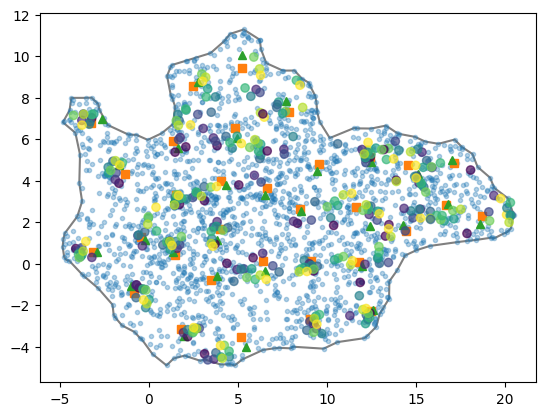

In [118]:
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values.T, '.', alpha=0.33, rasterized=True)
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values[center_ids].T, 's')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

plt.plot(*new_z_data.T, '^')

plt.scatter(*new_sims_embed.T, c=np.hstack(list(range(10))*32), zorder=2, alpha=0.67, rasterized=True)

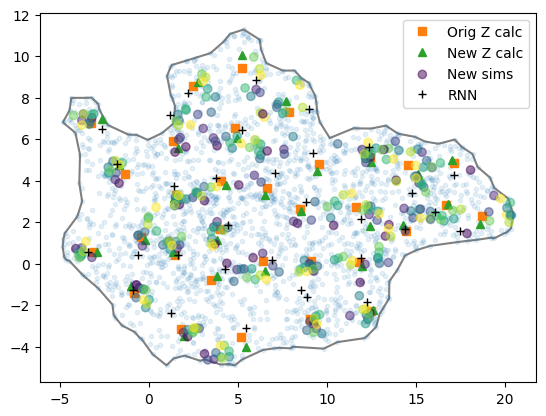

In [129]:
z_pred = json.loads("""[[4.292383193969727, -0.25006383657455444], [6.934352874755859, 0.17687058448791504], [8.823698997497559, 2.9980125427246094], [11.894545555114746, 2.165661334991455], [17.103500366210938, 4.284074306488037], [7.075537204742432, 4.372811317443848], [12.361146926879883, 5.613211631774902], [5.466960430145264, -3.094849109649658], [3.790335178375244, 4.1439361572265625], [1.1957086324691772, 7.1608123779296875], [14.7631196975708, 3.398747205734253], [9.233248710632324, 5.350840091705322], [-0.5818469524383545, 0.4395579695701599], [14.389513969421387, 1.6659637689590454], [1.4413098096847534, 3.74341082572937], [-2.647355556488037, 6.485861301422119], [16.047393798828125, 2.5074164867401123], [5.996227741241455, 8.871652603149414], [17.462554931640625, 1.5963369607925415], [5.255317211151123, 6.4647536277771], [-3.3975586891174316, 0.5558291673660278], [4.433489799499512, 1.8924119472503662], [8.554353713989258, -1.287595510482788], [8.862946510314941, -1.6008793115615845], [1.2286080121994019, -2.3590474128723145], [1.6243070363998413, 0.41344842314720154], [-1.7743982076644897, 4.815328121185303], [12.243847846984863, -1.845680594444275], [8.997865676879883, 7.481781959533691], [11.930590629577637, 0.29662853479385376], [-0.8598747253417969, -1.2871968746185303], [2.2153897285461426, 8.219918251037598]]""")
z_pred = np.array(z_pred)

plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values.T, '.', alpha=0.10, rasterized=True)
plt.plot(*orig_data.loc[:, 'Z0':'Z1'].values[center_ids].T, 's', label='Orig Z calc')
plt.plot(*orig_hull.T, '-', color='grey', zorder=-1)

plt.plot(*new_z_data.T, '^', label='New Z calc')

plt.scatter(*new_sims_embed.T, c=np.hstack(list(range(10))*32), zorder=2, alpha=0.50, rasterized=True, label='New sims')

plt.plot(*z_pred.T, 'k+', label='RNN')

plt.legend()

In [101]:
for k in embeddings.keys():
    print(k)

AAABBBBABBBAAAABAAAA
AABAAAAABBBABBBBAAAA
AABABABABBABBAAAABAA
ABAAAAABBABBBBAAABAA
ABABABABABAABABAABAA
ABABBABBBAAAAABAABAA
ABABBBAAAABAABAABABA
ABABBBBBBABAAAAAAAAA
ABBAAAAABBAABABBABAA
ABBABAAABAAAABABBBAA
ABBABABAABABABAAAABA
ABBBAAABAAABAAAABBBA
ABBBBBAAAAAAAABABABA
BAAAAABABBBAAABBAABA
BAAAABBABBAAAABBBAAA
BAAABBABAAABABABBAAA
BAAABBABABAABABAAAAB
BAABAAABAABAABBBABAA
BAABAAABBBABAAAABAAB
BAABAABABABAAABBBAAA
BABAABABAABABBBAAAAA
BABAABBABAABAAAAABBA
BABAABBABBBAAAAAABAA
BABABABABAABAAAAABAB
BABABBBAABABABAAAAAA
BABBAAABBABBAAAABAAA
BABBABAABAAAAABBABAA
BBAAAABABABBAAAAABAB
BBAABAABAABABAABABAA
BBABBAAAABAABABAAAAB
BBABBABAAABBAABAAAAA
BBBAABABAAAABAABABAA


In [102]:
"BAAAAABABBBAAABBAABA".count("B")

8

# k-mer tokens

i tried some different variants of this and they are terrible (rmse > 5) compared to the NNs

In [1230]:
import itertools
import tqdm.notebook
from math import factorial


def swap_monomers(seq):
    seq = seq.replace('A', 'C')
    seq = seq.replace('B', 'A')
    seq = seq.replace('C', 'B')
    return seq


def make_base(degree):
    # construct unique numbers of A/B monomers
    base = []
    for i in range(degree+1):
        for j in range(i):
            seq = ''.join(['A' for _ in range(i-j)] + ['B' for _ in range(j)])
            # print((i, j), seq)
            base += [''.join(x) for x in itertools.permutations(seq)]
            base += [''.join(x) for x in itertools.permutations(swap_monomers(seq))]
    base = sorted(set(base))
    pruned_base = []
    for b in base:
        if b not in pruned_base and b[::-1] not in pruned_base:
            pruned_base.append(b)
    base = pruned_base
    print(f'Finding {len(base)} patterns:', base)

    return base


def featurize(chain_sequences, base):
    X = np.zeros([len(chain_sequences), len(base)])
    for i, chain in tqdm.notebook.tqdm(enumerate(chain_sequences), total=len(chain_sequences)):
        if 'A' in str(chain):
            seq = chain
        else:
            seq = ''.join(['A' if x == 0 else 'B' for x in chain])
        X[i] = 0.5 * (np.array([seq.count(b) for b in base]) + np.array([seq[::-1].count(b) for b in base]))
    return X

In [987]:
data = {k: v for k, v in data.items() if k.count('B') == 8}
print(len(data))

2014


In [1402]:
from sklearn import preprocessing

base = make_base(degree=8)
train_keys = list(train_data.keys())
token_X_train = featurize(train_keys, base)
poly = preprocessing.PolynomialFeatures(degree=1)
poly.fit(token_X_train) 

x_train = poly.transform(token_X_train)
y_train = np.vstack([train_data[it] for it in train_keys])

test_keys = list(test_data.keys())
token_X_test = featurize(test_keys, base)
x_test = poly.transform(token_X_test)
y_test = np.vstack([test_data[it] for it in test_keys])

Finding 285 patterns: ['A', 'AA', 'AAA', 'AAAA', 'AAAAA', 'AAAAAA', 'AAAAAAA', 'AAAAAAAA', 'AAAAAAAB', 'AAAAAAB', 'AAAAAABA', 'AAAAAABB', 'AAAAAB', 'AAAAABA', 'AAAAABAA', 'AAAAABAB', 'AAAAABB', 'AAAAABBA', 'AAAAABBB', 'AAAAB', 'AAAABA', 'AAAABAA', 'AAAABAAA', 'AAAABAAB', 'AAAABAB', 'AAAABABA', 'AAAABABB', 'AAAABB', 'AAAABBA', 'AAAABBAA', 'AAAABBAB', 'AAAABBB', 'AAAABBBA', 'AAAABBBB', 'AAAB', 'AAABA', 'AAABAA', 'AAABAAA', 'AAABAAAB', 'AAABAAB', 'AAABAABA', 'AAABAABB', 'AAABAB', 'AAABABA', 'AAABABAA', 'AAABABAB', 'AAABABB', 'AAABABBA', 'AAABABBB', 'AAABB', 'AAABBA', 'AAABBAA', 'AAABBAAA', 'AAABBAAB', 'AAABBAB', 'AAABBABA', 'AAABBABB', 'AAABBB', 'AAABBBA', 'AAABBBAA', 'AAABBBAB', 'AAABBBB', 'AAABBBBA', 'AAABBBBB', 'AAB', 'AABA', 'AABAA', 'AABAAAAB', 'AABAAAB', 'AABAAABA', 'AABAAABB', 'AABAAB', 'AABAABA', 'AABAABAA', 'AABAABAB', 'AABAABB', 'AABAABBA', 'AABAABBB', 'AABAB', 'AABABA', 'AABABAA', 'AABABAAB', 'AABABAB', 'AABABABA', 'AABABABB', 'AABABB', 'AABABBA', 'AABABBAA', 'AABABBAB', 'AABAB

  0%|          | 0/1022 [00:00<?, ?it/s]

  0%|          | 0/256 [00:00<?, ?it/s]

In [1027]:
from sklearn import preprocessing

base = make_base(degree=3)
train_keys = list(train_data.keys())
token_X = featurize(train_keys, base)
poly = preprocessing.PolynomialFeatures(degree=1)
feature_X = poly.fit_transform(token_X)

# train_idx, test_idx = model_selection.train_test_split(np.arange(len(token_X)), train_size=0.90, random_state=0, shuffle=True)

token_y = np.vstack([train_data[it] for it in train_keys])
print(feature_X.shape, token_y.shape)

x_train = feature_X[train_idx]
y_train = token_y[train_idx]

x_test = feature_X[test_idx]
y_test = token_y[test_idx]

Finding 11 patterns: ['A', 'AA', 'AAA', 'AAB', 'AB', 'ABA', 'ABB', 'B', 'BAB', 'BB', 'BBB']


  0%|          | 0/1016 [00:00<?, ?it/s]

(1016, 12) (1016, 2)


In [1403]:
from sklearn import ensemble, linear_model, neighbors

model = ensemble.RandomForestRegressor(random_state=0, max_depth=None)
# model = linear_model.RidgeCV()
# model = neighbors.KNeighborsRegressor(n_neighbors=10, weights='distance')
model.fit(x_train, y_train)

# report metrics
pred = model.predict(x_train)
rmse = np.sqrt(np.mean(np.sum((pred - y_train)**2, axis=1)))
print('train:', rmse)

pred = model.predict(x_test)
rmse = np.sqrt(np.mean(np.sum((pred - y_test)**2, axis=1)))
print('test :', rmse)

train: 0.5005012572988027
test : 1.5138438310741835
